In [12]:
!unzip "diabetes+130-us+hospitals+for+years+1999-2008.zip"

unzip:  cannot find or open diabetes+130-us+hospitals+for+years+1999-2008.zip, diabetes+130-us+hospitals+for+years+1999-2008.zip.zip or diabetes+130-us+hospitals+for+years+1999-2008.zip.ZIP.


In [21]:
import pandas as pd

df = pd.read_csv("/diabetic_data.csv")

df.shape

(101766, 50)

In [22]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [23]:
!ls

sample_data


In [24]:
df.shape

(101766, 50)

In [25]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [26]:
capstone = df[['time_in_hospital', 'number_diagnoses' , 'num_medications', 'insulin']]
capstone.head()

,time_in_hospital,number_diagnoses,num_medications,insulin
0,1,1,1,No
1,3,9,18,Up
2,2,6,13,No
3,2,7,16,Up
4,1,5,8,Steady


In [27]:
capstone.isnull().sum()

,0
time_in_hospital,0
number_diagnoses,0
num_medications,0
insulin,0


In [28]:
capstone.describe()

,time_in_hospital,number_diagnoses,num_medications
count,101766.000000,101766.000000,101766.000000
mean,4.395987,7.422607,16.021844
std,2.985108,1.933600,8.127566
min,1.000000,1.000000,1.000000
25%,2.000000,6.000000,10.000000
50%,4.000000,8.000000,15.000000
75%,6.000000,9.000000,20.000000
max,14.000000,16.000000,81.000000


Question 1: Does the number of diagnoses relate to length of hospital stay?

In [29]:
capstone[['time_in_hospital' , 'number_diagnoses' ]].corr()

,time_in_hospital,number_diagnoses
time_in_hospital,1.000000,0.220186
number_diagnoses,0.220186,1.000000


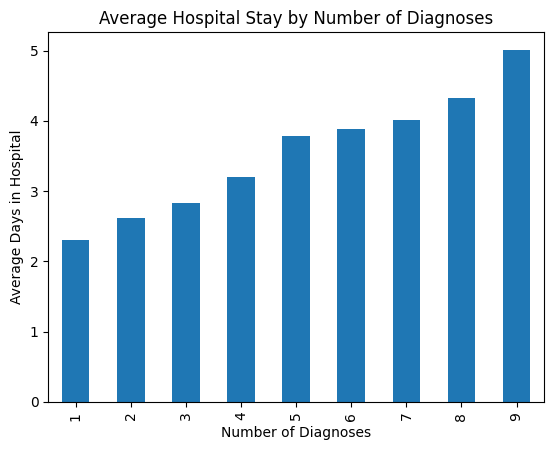

In [33]:
import matplotlib.pyplot as plt

counts = capstone['number_diagnoses'].value_counts()

valid_diagnoses = counts[counts>=100].index
filtered= capstone[capstone['number_diagnoses'].isin(valid_diagnoses)]
avg_stay = filtered.groupby('number_diagnoses')['time_in_hospital'].mean()
avg_stay.plot(kind='bar')
plt.xlabel('Number of Diagnoses')
plt.ylabel('Average Days in Hospital')
plt.title('Average Hospital Stay by Number of Diagnoses')
plt.show()

2.Does the number of medications relate to length of hospital stay?

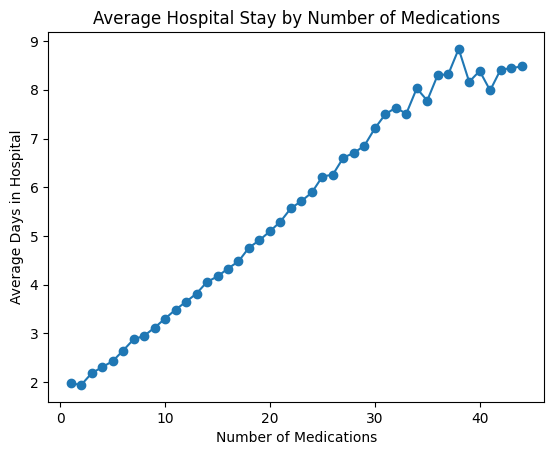

In [34]:
counts = capstone['num_medications'].value_counts()

valid_medications = counts[counts>=100].index
filtered_meds = capstone[capstone['num_medications'].isin(valid_medications)]

avg_med_stay = filtered_meds.groupby('num_medications')['time_in_hospital'].mean()

avg_med_stay.plot(kind='line', marker='o')

plt.xlabel('Number of Medications')
plt.ylabel('Average Days in Hospital')
plt.title('Average Hospital Stay by Number of Medications')

plt.show()

3.  Does length of stay differ based on insulin treatment status?

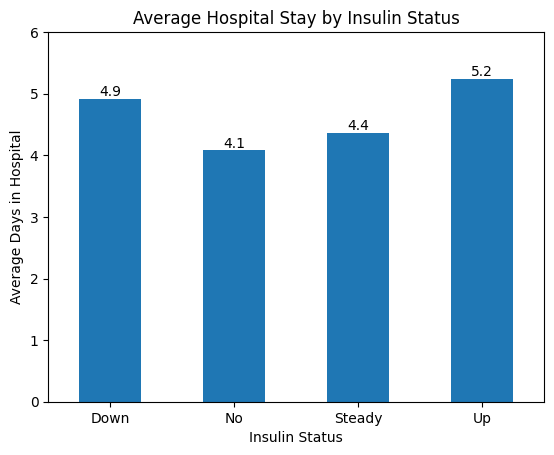

In [35]:
avg_insulin_stay = capstone.groupby('insulin')['time_in_hospital'].mean()

ax = avg_insulin_stay.plot(kind='bar')

plt.xlabel('Insulin Status')
plt.ylabel('Average Days in Hospital')
plt.title('Average Hospital Stay by Insulin Status')
plt.xticks(rotation=0)
plt.ylim(0, 6)

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.show()




In [36]:
capstone['time_in_hospital'].describe()

,time_in_hospital
count,101766.000000
mean,4.395987
std,2.985108
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,14.000000


In [37]:
capstone.groupby('insulin')['time_in_hospital'].mean()

,time_in_hospital
insulin,
Down,4.922164
No,4.079248
Steady,4.364193
Up,5.240809


In [38]:
capstone.groupby('insulin')['time_in_hospital'].agg(['mean','count'])

,mean,count
insulin,,
Down,4.922164,12218
No,4.079248,47383
Steady,4.364193,30849
Up,5.240809,11316


Conclusion

 Patients with more medications have more longer hospital stays and the "Up" insulin had the longest average stay at 5.2 days. Based on these results it suggest that there is a assocation between treatment related factors and hospital length of stay.

In [39]:
import matplotlib.pyplot as plt